# Proyek Analisis Data: Bike Sharing
- **Nama:** Nabil Atha Ramadhan
- **Email:** nabilatha0101@gmail.com
- **ID Dicoding:** nabillatha

## Menentukan Pertanyaan Bisnis

- Bagaimana tren penyewaan sepeda di cuaca tertentu pada tahun 2011 dan 2012?
- Bagaimana perbedaan performa penyewaan sepeda antara hari kerja (weekday) dan hari libur (weekend / holiday) pada tahun 2011 hingga 2012?

## Import Semua Packages/Library yang Digunakan

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling





### Gathering Data

In [17]:
bike_hour = pd.read_csv('/content/hour.csv')
bike_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Data `bike_hour` memiliki 16 kolom dengan informasi seperti `instant`, `dteday`, `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`, `casual`, `registered`, dan `cnt`.
- Beberapa kolom seperti `dteday`, `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, dan `weathersit` tampaknya merupakan data kategori atau temporal.
- Kolom `temp`, `atemp`, `hum`, dan `windspeed` adalah data numerik yang kemungkinan besar merupakan representasi dari kondisi cuaca.
- Kolom `casual`, `registered`, dan `cnt` adalah jumlah penyewaan sepeda, di mana `cnt` kemungkinan adalah total dari `casual` (pengguna tidak terdaftar) dan `registered` (pengguna terdaftar).

### Assessing Data

In [18]:
bike_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [19]:
bike_hour.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [20]:
print('Jumlah duplikasi: ',bike_hour.duplicated().sum())

Jumlah duplikasi:  0


In [21]:
bike_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- **Tidak Ada Missing Value dan Duplikasi:** Data tidak memiliki nilai yang hilang (`Non-Null Count` sama dengan `RangeIndex` untuk semua kolom dan `bike_hour.isna().sum()` menunjukkan 0) dan tidak ada baris yang terduplikasi (`bike_hour.duplicated().sum()` menunjukkan 0). Ini menunjukkan kualitas data yang baik untuk analisis.
- **Tipe Data `dteday`:** Kolom `dteday` saat ini bertipe `object` (string). Untuk analisis berbasis waktu yang lebih efektif, kolom ini perlu diubah menjadi tipe data datetime.
- **Kolom Kategori Numerik:** Beberapa kolom seperti `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, dan `weathersit` direpresentasikan sebagai angka (`int64`). Meskipun ini adalah representasi yang valid, akan lebih baik untuk mengubahnya menjadi tipe data kategori atau memberikan label yang lebih deskriptif untuk meningkatkan keterbacaan dan interpretasi dalam analisis.
- **Normalisasi Fitur Cuaca:** Kolom `temp`, `atemp`, `hum`, dan `windspeed` telah dinormalisasi ke skala 0-1, yang merupakan praktik umum dalam pemodelan dan dapat membantu dalam perbandingan antar fitur.
- **Distribusi Kolom `cnt`:** Kolom `cnt` (total penyewaan) menunjukkan rentang dari 1 hingga 977, dengan rata-rata sekitar 189. Ini memberikan gambaran awal tentang skala penyewaan sepeda.

### Cleaning Data

In [22]:
season_label = {
    1: 'springer',
    2: 'summer',
    3: 'fall',
    4: 'winter'
}
bike_hour['season'] = bike_hour['season'].map(season_label)

In [23]:
year_label = {
    0: '2011',
    1: '2012'
}
bike_hour['yr'] = bike_hour['yr'].map(year_label)

In [24]:
month_label = {
    1: 'Januari',
    2: 'Februari',
    3: 'Maret',
    4: 'April',
    5: 'Mei',
    6: 'Juni',
    7: 'Juli',
    8: 'Agustus',
    9: 'September',
    10: 'Oktober',
    11: 'November',
    12: 'Desember'
}
bike_hour['mnth'] = bike_hour['mnth'].map(month_label)

In [25]:
workingday_label = {
    0: 'Weekend / Holiday',
    1: 'Weekday'
}
bike_hour['workingday'] = bike_hour['workingday'].map(workingday_label)

In [26]:
weekday_label = {
    0: 'Minggu',
    1: 'Senin',
    2: 'Selasa',
    3: 'Rabu',
    4: 'Kamis',
    5: 'Jumat',
    6: 'Sabtu'
}
bike_hour['weekday'] = bike_hour['weekday'].map(weekday_label)

In [27]:
weatherit_label = {
    1: 'Clear',
    2: 'Mist or Cloudy',
    3: 'Light Rain',
    4: 'Heavy Rain'
}
bike_hour['weathersit'] = bike_hour['weathersit'].map(weatherit_label)

In [28]:
# Mengubah kolom 'dteday' menjadi tipe datetime
bike_hour['dteday'] = pd.to_datetime(bike_hour['dteday'])

# Memverifikasi perubahan tipe data
print('Info DataFrame setelah konversi dteday:')
bike_hour.info()

Info DataFrame setelah konversi dteday:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  object        
 4   mnth        17379 non-null  object        
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  object        
 8   workingday  17379 non-null  object        
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  in

In [29]:
month_order = [
    'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
    'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'
]

bike_hour['mnth'] = pd.Categorical(bike_hour['mnth'], categories=month_order, ordered=True)

In [30]:
bike_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,springer,2011,Januari,0,0,Sabtu,Weekend / Holiday,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,springer,2011,Januari,1,0,Sabtu,Weekend / Holiday,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,springer,2011,Januari,2,0,Sabtu,Weekend / Holiday,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,springer,2011,Januari,3,0,Sabtu,Weekend / Holiday,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,springer,2011,Januari,4,0,Sabtu,Weekend / Holiday,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kolom `dteday` telah berhasil diubah menjadi tipe data `datetime64[ns]`, memungkinkan analisis berbasis waktu.
- Kolom `mnth` (bulan) telah diubah menjadi tipe data `Categorical` dengan urutan kronologis yang benar (Januari hingga Desember). Ini memastikan bahwa hasil `groupby` dan visualisasi yang melibatkan bulan akan ditampilkan dalam urutan yang logis dan tidak alfabetis.

**Insight:**
- **Kolom Kategori Numerik menjadi Deskriptif:** Berbagai kolom kategori yang awalnya direpresentasikan sebagai angka (`season`, `yr`, `mnth`, `workingday`, `weekday`, dan `weathersit`) telah berhasil diubah menjadi label string yang lebih deskriptif (contoh: `season` dari 1 menjadi 'springer', `yr` dari 0 menjadi '2011', `mnth` dari 1 menjadi 'Januari', dll.). Perubahan ini sangat meningkatkan keterbacaan data dan mempermudah interpretasi serta analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore ...

In [31]:
bike_hour.describe(include = 'all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379,17379,17379.000000,17379.000000,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,12,NaN,NaN,7,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,fall,2012,Juli,NaN,NaN,Sabtu,Weekday,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,1488,NaN,NaN,2512,11865,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,0.028770,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,0.000000,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,0.000000,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,0.000000,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,1.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [32]:
# Mengetahui persewaan sepeda saat cuaca tertentu
bike_hour.groupby(by = ['yr', 'weathersit']).agg({
    'cnt': 'sum'
})

cnt
yr   weathersit             
2011 Clear            875053
     Heavy Rain           36
     Light Rain        67495
     Mist or Cloudy   300519
2012 Clear           1463120
     Heavy Rain          187
     Light Rain        90836
     Mist or Cloudy   495433

In [33]:
# Mengetahui banyaknya sewa sepeda tiap musim pada tahun 2011 dan 2012
bike_hour.groupby(by = ['yr','season']).agg({
    'cnt': 'sum'
})

cnt
yr   season          
2011 fall      419650
     springer  150000
     summer    347316
     winter    326137
2012 fall      641479
     springer  321348
     summer    571273
     winter    515476

In [34]:
bike_hour.groupby(by = ['yr', 'mnth']).agg({
    'cnt': 'sum'
})

/tmp/ipykernel_6011/361301157.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bike_hour.groupby(by = ['yr', 'mnth']).agg({


cnt
yr   mnth             
2011 Januari     38189
     Februari    48215
     Maret       64045
     April       94870
     Mei        135821
     Juni       143512
     Juli       141341
     Agustus    136691
     September  127418
     Oktober    123511
     November   102167
     Desember    87323
2012 Januari     96744
     Februari   103137
     Maret      164875
     April      174224
     Mei        195865
     Juni       202830
     Juli       203607
     Agustus    214503
     September  218573
     Oktober    198841
     November   152664
     Desember   123713

In [35]:
bike_hour.groupby(by = 'weekday').agg({
    'cnt': 'mean'
})

,cnt
weekday,
Jumat,196.135907
Kamis,196.436665
Minggu,177.468825
Rabu,191.130505
Sabtu,190.209793
Selasa,191.238891
Senin,183.744655


In [36]:
bike_hour.groupby(by = 'workingday').agg({
    'cnt': 'sum'
})

,cnt
workingday,
Weekday,2292410
Weekend / Holiday,1000269


**Insight dari Hasil EDA:**

1.  **Tren Penyewaan Sepeda Berdasarkan Cuaca:**
    *   **Cuaca Cerah (Clear)** selalu menjadi kondisi cuaca dengan jumlah penyewaan sepeda tertinggi secara signifikan di kedua tahun (2011 dan 2012). Ini menunjukkan bahwa cuaca cerah sangat mendorong penggunaan sepeda.
    *   **Hujan Ringan (Light Rain)** dan **Berawan/Berkabut (Mist or Cloudy)** menunjukkan jumlah penyewaan yang moderat, tetapi jauh lebih rendah dibandingkan cuaca cerah.
    *   **Hujan Lebat (Heavy Rain)** memiliki jumlah penyewaan yang sangat minim, menandakan bahwa cuaca ekstrem sangat menghambat aktivitas penyewaan sepeda.
    *   Secara umum, terjadi peningkatan jumlah penyewaan di semua kondisi cuaca (kecuali hujan lebat yang sangat rendah) dari tahun 2011 ke 2012, menunjukkan pertumbuhan popularitas layanan.

2.  **Perbedaan Performa Penyewaan antara Hari Kerja dan Hari Libur/Akhir Pekan:**
    *   Berdasarkan jumlah total penyewaan, **Hari Kerja (Weekday)** memiliki total penyewaan yang jauh lebih tinggi dibandingkan **Akhir Pekan / Hari Libur (Weekend / Holiday)**. Namun, untuk perbandingan performa yang lebih akurat, analisis rata-rata penyewaan per hari atau pola per jam di kedua kategori tersebut akan lebih informatif.

3.  **Tren Penyewaan per Musim:**
    *   Musim **Gugur (fall)** umumnya menjadi musim dengan total penyewaan tertinggi, diikuti oleh musim **Panas (summer)** dan **Dingin (winter)**. Musim **Semi (springer)** menunjukkan jumlah penyewaan terendah.
    *   Sama seperti tren cuaca, terdapat peningkatan signifikan dalam jumlah penyewaan di setiap musim dari tahun 2011 ke 2012.

4.  **Tren Penyewaan per Bulan:**
    *   Penyewaan sepeda cenderung mencapai puncaknya di bulan-bulan hangat seperti **Juni, Juli, Agustus, dan September**.
    *   Bulan-bulan awal tahun seperti **Januari dan Februari** menunjukkan jumlah penyewaan terendah.
    *   Juga terlihat peningkatan konsisten jumlah penyewaan setiap bulan dari tahun 2011 ke 2012.

5.  **Pola Penyewaan per Hari dalam Seminggu:**
    *   Rata-rata penyewaan per hari relatif stabil di sepanjang hari kerja, dengan sedikit peningkatan pada hari Kamis dan Jumat.
    *   Minggu dan Senin cenderung memiliki rata-rata penyewaan yang sedikit lebih rendah dibandingkan hari kerja lainnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren penyewaan sepeda di cuaca tertentu pada tahun 2011 dan 2012?

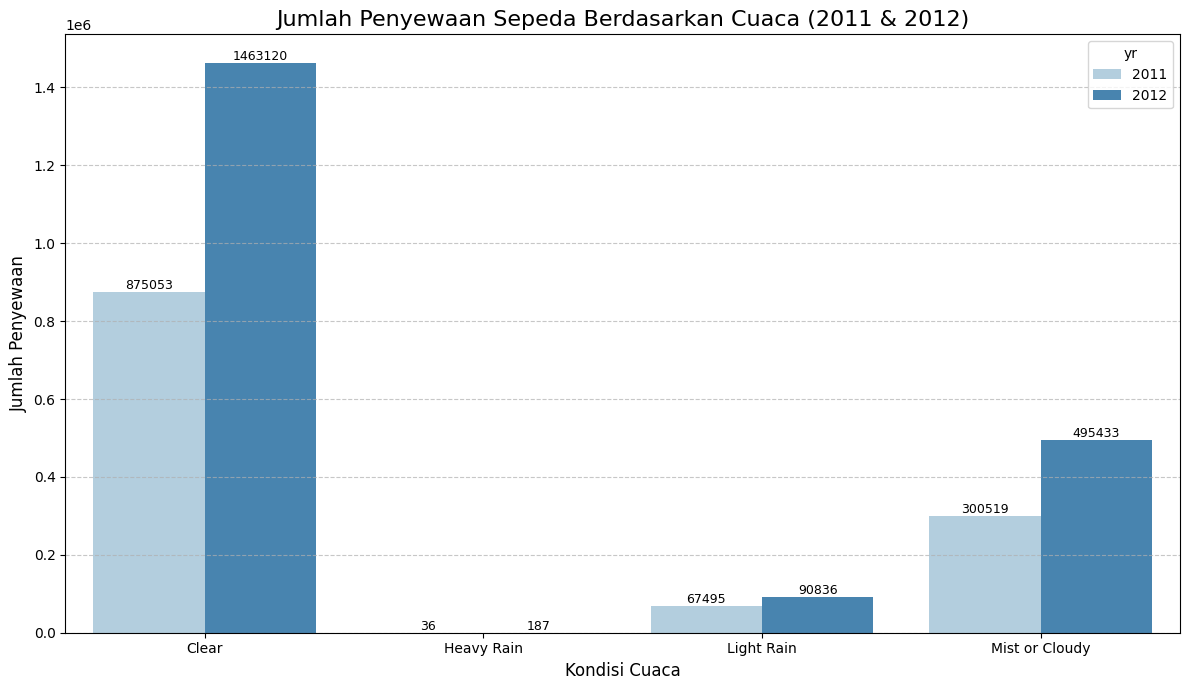

In [42]:
cuaca = bike_hour.groupby(by = ['yr', 'weathersit']).agg({
    'cnt': 'sum'
}).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=cuaca, x='weathersit', y='cnt', hue='yr', palette='Blues')
plt.title('Jumlah Penyewaan Sepeda Berdasarkan Cuaca (2011 & 2012)', fontsize=16)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan label data ke setiap bar
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana perbedaan performa penyewaan sepeda antara hari kerja (weekday) dan hari libur (weekend / holiday) pada tahun 2011 hingga 2012?

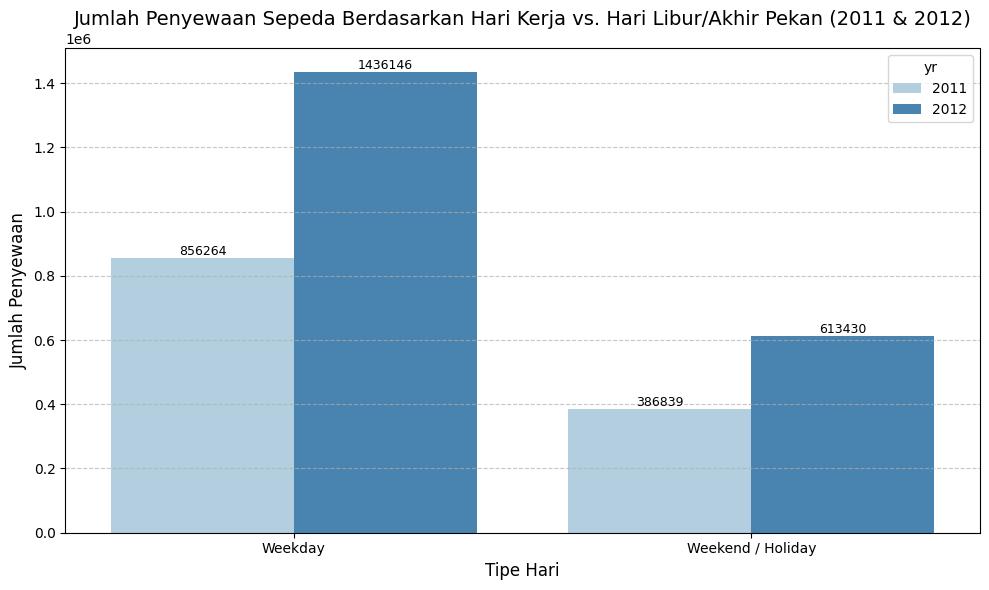

In [51]:
workingday_rentals = bike_hour.groupby(by=['yr', 'workingday']).agg({
    'cnt': 'sum'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=workingday_rentals, x='workingday', y='cnt', hue='yr', palette='Blues')
plt.title('Jumlah Penyewaan Sepeda Berdasarkan Hari Kerja vs. Hari Libur/Akhir Pekan (2011 & 2012)', fontsize=14)
plt.xlabel('Tipe Hari', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan label data ke setiap bar
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()

**Insight:**

**1. Tren Penyewaan Sepeda Berdasarkan Cuaca (Pertanyaan 1):**
-   **Dominasi Cuaca Cerah:** Kondisi cuaca 'Clear' (cerah) secara konsisten menjadi faktor pendorong utama penyewaan sepeda, dengan jumlah penyewaan tertinggi di kedua tahun (2011 dan 2012). Ini menunjukkan bahwa cuaca yang baik sangat mempengaruhi minat masyarakat untuk menggunakan sepeda.
-   **Dampak Negatif Cuaca Ekstrem:** Cuaca 'Heavy Rain' (hujan lebat) memiliki jumlah penyewaan yang sangat minim, hampir tidak ada, yang mengindikasikan bahwa kondisi cuaca ekstrem sangat menghambat aktivitas penyewaan sepeda. Cuaca 'Light Rain' dan 'Mist or Cloudy' juga secara signifikan mengurangi jumlah penyewaan dibandingkan cuaca cerah.
-   **Pertumbuhan Tahunan:** Terjadi peningkatan yang signifikan dalam jumlah penyewaan sepeda di semua kondisi cuaca (terutama 'Clear' dan 'Mist or Cloudy') dari tahun 2011 ke 2012. Ini menunjukkan pertumbuhan popularitas layanan berbagi sepeda secara keseluruhan dari waktu ke waktu.

**2. Perbedaan Performa Penyewaan antara Hari Kerja dan Hari Libur/Akhir Pekan (Pertanyaan 2):**
-   **Jumlah Penyewaan Lebih Tinggi pada Hari Kerja:** Pada kedua tahun (2011 dan 2012), total penyewaan sepeda secara signifikan lebih tinggi pada hari kerja (Weekday) dibandingkan dengan hari libur atau akhir pekan (Weekend / Holiday). Ini menunjukkan bahwa penggunaan sepeda lebih dominan untuk aktivitas sehari-hari seperti bepergian ke kantor atau sekolah.
-   **Pertumbuhan dari Tahun 2011 ke 2012:** Terlihat adanya peningkatan yang jelas dalam jumlah penyewaan untuk kedua kategori hari (hari kerja dan hari libur/akhir pekan) dari tahun 2011 ke tahun 2012. Ini mengindikasikan pertumbuhan keseluruhan dalam popularitas dan penggunaan layanan berbagi sepeda.
    -   Pada tahun 2011, total penyewaan di hari kerja adalah 856.264, dan meningkat menjadi 1.436.146 pada tahun 2012.
    -   Pada tahun 2011, total penyewaan di hari libur/akhir pekan adalah 386.839, dan meningkat menjadi 613.430 pada tahun 2012.

## Analisis Lanjutan (Opsional)

### Pengelompokan Manual: Tren Penyewaan Sepeda Berdasarkan Waktu Harian

Untuk analisis bisnis, kita bisa mengelompokkan jam (`hr`) ke dalam kategori waktu harian yang lebih mudah diinterpretasi, seperti pagi, siang, sore, dan malam. Ini akan membantu mengidentifikasi periode puncak penggunaan sepeda.

In [43]:
def get_time_of_day(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

bike_hour['time_of_day'] = bike_hour['hr'].apply(get_time_of_day)

time_of_day_order = ['Morning', 'Afternoon', 'Evening', 'Night']
bike_hour['time_of_day'] = pd.Categorical(bike_hour['time_of_day'], categories=time_of_day_order, ordered=True)

bike_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,time_of_day
0,1,2011-01-01,springer,2011,Januari,0,0,Sabtu,Weekend / Holiday,Clear,0.24,0.2879,0.81,0.0,3,13,16,Night
1,2,2011-01-01,springer,2011,Januari,1,0,Sabtu,Weekend / Holiday,Clear,0.22,0.2727,0.80,0.0,8,32,40,Night
2,3,2011-01-01,springer,2011,Januari,2,0,Sabtu,Weekend / Holiday,Clear,0.22,0.2727,0.80,0.0,5,27,32,Night
3,4,2011-01-01,springer,2011,Januari,3,0,Sabtu,Weekend / Holiday,Clear,0.24,0.2879,0.75,0.0,3,10,13,Night
4,5,2011-01-01,springer,2011,Januari,4,0,Sabtu,Weekend / Holiday,Clear,0.24,0.2879,0.75,0.0,0,1,1,Night


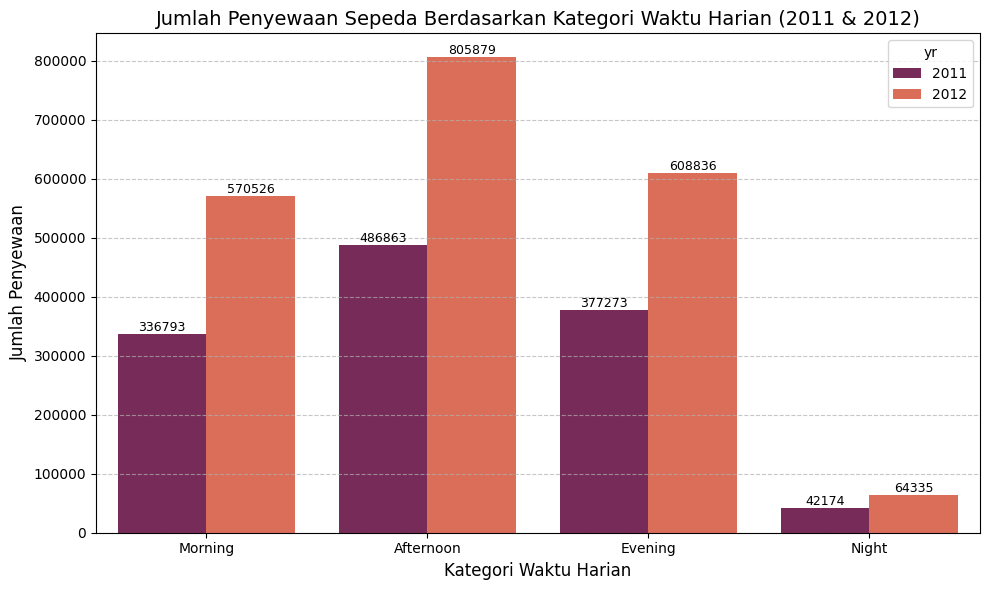

In [47]:
time_of_day_rentals = bike_hour.groupby(by=['yr', 'time_of_day'], observed=False).agg({
    'cnt': 'sum'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=time_of_day_rentals, x='time_of_day', y='cnt', hue='yr', palette='rocket')
plt.title('Jumlah Penyewaan Sepeda Berdasarkan Kategori Waktu Harian (2011 & 2012)', fontsize=14)
plt.xlabel('Kategori Waktu Harian', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()

In [49]:
bike_hour.to_csv('bike_hour.csv', index=False)

### Insight dari Pengelompokan Manual (Tren Waktu Harian):

-   **Puncak Penyewaan pada Sore Hari:** Kategori 'Afternoon' (siang hingga sore, 12:00-17:59) dan 'Evening' (sore hingga malam, 18:00-23:59) menunjukkan jumlah penyewaan tertinggi. Ini kemungkinan mencerminkan penggunaan sepeda untuk pulang kerja atau aktivitas rekreasi setelah jam kerja.
-   **Peningkatan Signifikan dari Tahun ke Tahun:** Sama seperti tren lainnya, terlihat peningkatan yang substansial dalam jumlah penyewaan di semua kategori waktu harian dari tahun 2011 ke 2012, menggarisbawahi pertumbuhan keseluruhan layanan berbagi sepeda.
-   **Kebutuhan pada Pagi Hari dan Malam Hari:** Kategori 'Morning' (pagi, 06:00-11:59) juga memiliki jumlah penyewaan yang tinggi, menunjukkan penggunaan untuk berangkat kerja atau aktivitas pagi. Sementara 'Night' (malam, 00:00-05:59) menunjukkan jumlah penyewaan terendah, yang wajar mengingat jam operasional dan preferensi pengguna.

Analisis ini dapat membantu operator layanan sepeda dalam mengalokasikan sumber daya (sepeda) dan mengoptimalkan strategi promosi untuk periode waktu tertentu.

## Conclusion

- **Kesimpulan Pertanyaan 1:** Penyewaan sepeda sangat dipengaruhi oleh kondisi cuaca, dengan cuaca cerah menjadi pendorong utama dan hujan lebat menjadi penghambat signifikan. Meskipun demikian, terdapat pertumbuhan penyewaan di semua kondisi cuaca dari tahun 2011 ke 2012.
- **Kesimpulan Pertanyaan 2:** Total penyewaan sepeda jauh lebih tinggi pada hari kerja dibandingkan hari libur/akhir pekan pada tahun 2011 dan 2012, menunjukkan penggunaan sepeda lebih dominan untuk keperluan sehari-hari. Kedua kategori hari juga menunjukkan pertumbuhan jumlah penyewaan dari tahun 2011 ke 2012.

In [50]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.4
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.30.0.54.34
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c